# Green & Fast Delivery — Machine Learning MVP

<br>

<p align="center">
  <img src="https://cdn-icons-png.flaticon.com/512/2972/2972185.png" width="120">
</p>

<br>


## Cadre académique

- **Module** : Machine Learning supervisé avec Python
- **Programme** : NEXA School IA — Master 1

<br>

## Équipe projet

- BAITE Camille
- CASTERAS Maxime
- DELGADO David
-
## Contexte

Ce projet s’inscrit dans le cadre du module de **Machine Learning supervisé avec Python**.

Il répond à un besoin métier formulé par Eco-Delivery :
optimiser la gestion des livraisons afin de réduire les délais et l’empreinte carbone.

L’objectif est de construire rapidement un **MVP fonctionnel** capable de fournir une première estimation prédictive à partir des données disponibles.

<br>



## Objectifs

- Mettre en place un pipeline de données complet (chargement, nettoyage, transformation)
- Gérer les valeurs manquantes et la qualité des données
- Identifier une variable cible pertinente
- Construire un modèle baseline simple
- Évaluer les performances du modèle
- Fournir une solution reproductible et exploitable

<br>

## Approche (XP / Agile)

Le projet suit une logique **Extreme Programming (XP)** :

- Livraison rapide d’un prototype fonctionnel
- Simplicité des solutions (baseline avant optimisation)
- Code lisible et modulaire
- Amélioration itérative

L’objectif n’est pas d’obtenir le meilleur modèle, mais de **livrer de la valeur rapidement**.

<br>

## Données

Dataset utilisé :
https://www.kaggle.com/datasets/gauravmalik26/food-delivery-dataset

Les données contiennent :
- Informations sur les commandes
- Données temporelles
- Informations sur les livraisons

<br>



## Pipeline

Le pipeline mis en place comprend :

1. Chargement des données
2. Nettoyage :
   - gestion des valeurs manquantes
3. Transformation :
   - variables numériques → normalisation
   - variables catégorielles → encodage
4. Modélisation :
   - modèle baseline (SGDClassifier)
5. Évaluation :
   - accuracy
   - classification report

<br>

## Modèle

Le modèle utilisé est :

- **SGDClassifier**

Choix volontaire :
- rapide
- simple
- adapté à une première itération

Ce modèle sert de **baseline** pour valider le pipeline.

<br>


<br>
<br>
<br>

## **1. Introduction du projet**

Ce projet vise à construire un modèle de Machine Learning permettant d’analyser et de prédire des comportements liés aux livraisons de repas à partir de données opérationnelles.

L’objectif est double :
- comprendre les facteurs influençant la performance des livraisons (temps, efficacité, répartition)
- développer un modèle baseline capable de produire une première prédiction exploitable

Le projet s’inscrit dans une logique MVP, avec une approche Agile (XP), privilégiant la livraison rapide d’un pipeline fonctionnel avant toute optimisation avancée.

In [599]:
import os
import pandas as pd
import numpy as np

from sklearn.pipeline import make_pipeline
from sklearn.compose import make_column_selector, make_column_transformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import SGDClassifier
from sklearn.impute import SimpleImputer
from sklearn.metrics import classification_report, accuracy_score

import kagglehub

In [600]:
def load_data(train_path: str, test_path: str) -> tuple:
    """
    Charge les datasets d'entraînement et de test depuis les fichiers.

    Paramètres
    ----------
    train_path : str
        Chemin vers le fichier train.csv
    test_path : str
        Chemin vers le fichier test.csv

    Retour
    -------
    df_train : pd.DataFrame
        Dataset d'entraînement
    df_test : pd.DataFrame
        Dataset de test
    """
    df_train = pd.read_csv(train_path)
    df_test = pd.read_csv(test_path)

    return df_train, df_test

In [601]:
df_train, df_test = load_data("../data/train.csv", "../data/test.csv")

In [602]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45593 entries, 0 to 45592
Data columns (total 20 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   ID                           45593 non-null  object 
 1   Delivery_person_ID           45593 non-null  object 
 2   Delivery_person_Age          45593 non-null  object 
 3   Delivery_person_Ratings      45593 non-null  object 
 4   Restaurant_latitude          45593 non-null  float64
 5   Restaurant_longitude         45593 non-null  float64
 6   Delivery_location_latitude   45593 non-null  float64
 7   Delivery_location_longitude  45593 non-null  float64
 8   Order_Date                   45593 non-null  object 
 9   Time_Orderd                  45593 non-null  object 
 10  Time_Order_picked            45593 non-null  object 
 11  Weatherconditions            45593 non-null  object 
 12  Road_traffic_density         45593 non-null  object 
 13  Vehicle_conditio

In [603]:
df_test.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11399 entries, 0 to 11398
Data columns (total 19 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   ID                           11399 non-null  object 
 1   Delivery_person_ID           11399 non-null  object 
 2   Delivery_person_Age          11399 non-null  object 
 3   Delivery_person_Ratings      11399 non-null  object 
 4   Restaurant_latitude          11399 non-null  float64
 5   Restaurant_longitude         11399 non-null  float64
 6   Delivery_location_latitude   11399 non-null  float64
 7   Delivery_location_longitude  11399 non-null  float64
 8   Order_Date                   11399 non-null  object 
 9   Time_Orderd                  11399 non-null  object 
 10  Time_Order_picked            11399 non-null  object 
 11  Weatherconditions            11399 non-null  object 
 12  Road_traffic_density         11399 non-null  object 
 13  Vehicle_conditio

In [604]:
def add_split_flag(df_train: pd.DataFrame, df_test: pd.DataFrame) -> pd.DataFrame:
    """
    Ajoute un indicateur permettant de distinguer les données train et test,
    puis concatène les deux datasets.

    Objectif
    --------
    - Permettre un preprocessing global (nettoyage, encoding, etc.)
    - Éviter toute confusion entre train et test après concaténation

    Retour
    -------
    df_all : pd.DataFrame
        Dataset combiné avec indicateur is_train
    """
    df_train = df_train.copy()
    df_test = df_test.copy()

    # Indicateur d'origine des données (1 = train, 0 = test)
    df_train["is_train"] = 1
    df_test["is_train"] = 0

    # Ajouter la target au test si absente (nécessaire pour concat)
    if "Time_taken(min)" not in df_test.columns:
        df_test["Time_taken(min)"] = None

    # Concaténation pour traitement unifié
    df_all = pd.concat([df_train, df_test], axis=0).reset_index(drop=True)

    return df_all

In [605]:
df_all_info = add_split_flag(df_train, df_test)

df = df_train


In [606]:
def get_distribution(df: pd.DataFrame, column: str) -> pd.DataFrame:
    """
    Calcule le nombre et le pourcentage de chaque valeur d'une colonne.

    Paramètres
    ----------
    df : pd.DataFrame
    column : str
        Colonne à analyser

    Retour
    -------
    pd.DataFrame
        Tableau avec count et percentage
    """
    counts = df[column].value_counts()
    percentages = df[column].value_counts(normalize=True) * 100

    result = pd.DataFrame({
        "count": counts,
        "percentage": percentages.round(2)
    })

    return result


In [607]:
# Utilisation
dist = get_distribution(df_all_info, "is_train")
print(dist)

          count  percentage
is_train                   
1         45593        80.0
0         11399        20.0


In [608]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


def analyze_missing_by_type(df: pd.DataFrame) -> pd.DataFrame:
    """
    Analyse avancée des valeurs manquantes par type de variable.
    """
    result = []

    total = len(df)

    for col in df.columns:
        missing = df[col].isna().sum()
        pct = (missing / total) * 100

        dtype = df[col].dtype

        if pd.api.types.is_numeric_dtype(df[col]):
            col_type = "numerical"
        elif pd.api.types.is_datetime64_any_dtype(df[col]):
            col_type = "datetime"
        else:
            col_type = "categorical"

        result.append({
            "column": col,
            "type": col_type,
            "dtype": dtype,
            "missing_count": missing,
            "missing_pct": round(pct, 2)
        })

    return pd.DataFrame(result).sort_values(by="missing_pct", ascending=False)



def clean_strings(df: pd.DataFrame, verbose: bool = True) -> pd.DataFrame:

    """
    Nettoie les colonnes texte + affiche impact avant/après.

    Actions
    -------
    - trim espaces
    - remplacement "NaN", "" → pd.NA

    Paramètre
    ---------
    verbose : bool
        Affiche les stats avant/après
    """

    df = df.copy()

    if verbose:
        print("=== AVANT CLEAN ===")
        print(analyze_missing_by_type(df)[lambda x: x["missing_count"] > 0])

    # seulement sur colonnes object
    obj_cols = df.select_dtypes(include="object").columns

    for col in obj_cols:
        df[col] = df[col].apply(lambda x: x.strip() if isinstance(x, str) else x)

    df = df.replace(["NaN", "nan", ""], pd.NA)

    if verbose:
        print("\n=== APRÈS CLEAN ===")
        print(analyze_missing_by_type(df)[lambda x: x["missing_count"] > 0])

    return df


def impute_missing_values(
    df: pd.DataFrame,
    strategy_config: dict = None,
    default_num: str = "median",
    default_cat: str = "mode",
    default_datetime: str = "median",
    verbose: bool = True
) -> pd.DataFrame:

    df = df.copy()

    if verbose:
        print("=== AVANT IMPUTATION ===")
        print(analyze_missing_by_type(df)[lambda x: x["missing_count"] > 0])

    for col in df.columns:
        if df[col].isna().sum() == 0:
            continue

        # FIX CRITIQUE ML : ne jamais imputer la target
        if col == "Time_taken(min)":
            continue

        strategy = None
        if strategy_config and col in strategy_config:
            strategy = strategy_config[col]

        if strategy is None:
            if pd.api.types.is_numeric_dtype(df[col]):
                strategy = default_num
            elif pd.api.types.is_datetime64_any_dtype(df[col]):
                strategy = default_datetime
            else:
                strategy = default_cat

        if strategy == "drop":
            df = df[df[col].notna()]

        elif strategy == "mean":
            df[col] = df[col].fillna(df[col].mean())

        elif strategy == "median":
            df[col] = df[col].fillna(df[col].median())

        elif strategy == "mode":
            df[col] = df[col].fillna(df[col].mode(dropna=True)[0])

        elif strategy.startswith("constant:"):
            value = strategy.split(":")[1]
            df[col] = df[col].fillna(value)

    if verbose:
        print("\n=== APRÈS IMPUTATION ===")
        print(analyze_missing_by_type(df)[lambda x: x["missing_count"] > 0])

    return df


def convert_types(df: pd.DataFrame) -> pd.DataFrame:
    """
    Convertit les colonnes vers les bons types.

    Objectif
    --------
    - Transformer les colonnes numériques stockées en texte
    - Nettoyer la variable cible
    """
    df = df.copy()

    # Variables numériques (actuellement en string)
    df["Delivery_person_Age"] = pd.to_numeric(df["Delivery_person_Age"], errors="coerce")
    df["Delivery_person_Ratings"] = pd.to_numeric(df["Delivery_person_Ratings"], errors="coerce")
    df["multiple_deliveries"] = pd.to_numeric(df["multiple_deliveries"], errors="coerce")

    # Target : "30 (min)" → 30
    if "Time_taken(min)" in df.columns:
        df["Time_taken(min)"] = df["Time_taken(min)"].astype(str).str.extract(r"(\d+)").astype(float)

    return df


# =========================================================
# VISUALISATION
# =========================================================

def plot_missing(df: pd.DataFrame, title: str = "") -> None:
    summary = analyze_missing_by_type(df)
    summary = summary[summary["missing_count"] > 0]

    if summary.empty:
        print(f"{title} : aucune valeur manquante")
        return

    plot_df = summary.copy()
    plot_df["non_missing_pct"] = 100 - plot_df["missing_pct"]
    plot_df = plot_df.sort_values(by="missing_pct", ascending=True)

    plt.figure(figsize=(10, 6))

    plt.barh(
        plot_df["column"],
        plot_df["missing_pct"],
        label="Missing",
        color="red"
    )

    plt.barh(
        plot_df["column"],
        plot_df["non_missing_pct"],
        left=plot_df["missing_pct"],
        label="Non-missing",
        color="green"
    )

    plt.xlabel("Percentage")
    plt.title(title)

    plt.legend()
    plt.tight_layout()
    plt.show()

In [609]:
df

,ID,Delivery_person_ID,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Order_Date,Time_Orderd,Time_Order_picked,Weatherconditions,Road_traffic_density,Vehicle_condition,Type_of_order,Type_of_vehicle,multiple_deliveries,Festival,City,Time_taken(min)
0,0x4607,INDORES13DEL02,37,4.9,22.745049,75.892471,22.765049,75.912471,19-03-2022,11:30:00,11:45:00,conditions Sunny,High,2,Snack,motorcycle,0,No,Urban,(min) 24
1,0xb379,BANGRES18DEL02,34,4.5,12.913041,77.683237,13.043041,77.813237,25-03-2022,19:45:00,19:50:00,conditions Stormy,Jam,2,Snack,scooter,1,No,Metropolitian,(min) 33
2,0x5d6d,BANGRES19DEL01,23,4.4,12.914264,77.678400,12.924264,77.688400,19-03-2022,08:30:00,08:45:00,conditions Sandstorms,Low,0,Drinks,motorcycle,1,No,Urban,(min) 26
3,0x7a6a,COIMBRES13DEL02,38,4.7,11.003669,76.976494,11.053669,77.026494,05-04-2022,18:00:00,18:10:00,conditions Sunny,Medium,0,Buffet,motorcycle,1,No,Metropolitian,(min) 21
4,0x70a2,CHENRES12DEL01,32,4.6,12.972793,80.249982,13.012793,80.289982,26-03-2022,13:30:00,13:45:00,conditions Cloudy,High,1,Snack,scooter,1,No,Metropolitian,(min) 30
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45588,0x7c09,JAPRES04DEL01,30,4.8,26.902328,75.794257,26.912328,75.804257,24-03-2022,11:35:00,11:45:00,conditions Windy,High,1,Meal,motorcycle,0,No,Metropolitian,(min) 32
45589,0xd641,AGRRES16DEL01,21,4.6,0.000000,0.000000,0.070000,0.070000,16-02-2022,19:55:00,20:10:00,conditions Windy,Jam,0,Buffet,motorcycle,1,No,Metropolitian,(min) 36
45590,0x4f8d,CHENRES08DEL03,30,4.9,13.022394,80.242439,13.052394,80.272439,11-03-2022,23:50:00,00:05:00,conditions Cloudy,Low,1,Drinks,scooter,0,No,Metropolitian,(min) 16
45591,0x5eee,COIMBRES11DEL01,20,4.7,11.001753,76.986241,11.041753,77.026241,07-03-2022,13:35:00,13:40:00,conditions Cloudy,High,0,Snack,motorcycle,1,No,Metropolitian,(min) 26


In [610]:
# =========================
# TARGET
# =========================
target_col = "Time_taken(min)"

# =========================
# CONFIG IMPUTATION
# =========================
strategy_config = {
    "Delivery_person_Age": "median",
    "Delivery_person_Ratings": "median",
    "multiple_deliveries": "median",

    "Festival": "constant:No",
    "City": "mode",
    "Road_traffic_density": "mode",

    "order_hour": "median",
    "pickup_hour": "median",

    "Order_Year": "median",
    "Order_Month": "median",
    "Order_Day": "median",
    "Order_weekday": "median"
}

In [611]:
def clean_target_numeric(df: pd.DataFrame, col: str) -> pd.DataFrame:
    """
    Nettoie une colonne cible contenant du texte type '30 (min)'
    et la convertit en numérique (float).

    Étapes :
    - extraction des nombres
    - conversion en float
    - suppression des lignes NaN

    Paramètres
    ----------
    df : DataFrame
    col : nom de la colonne cible

    Retour
    ------
    DataFrame nettoyé
    """
    df = df.copy()

    df[col] = (
        df[col]
        .astype(str)
        .str.extract(r"(\d+)")
        .astype(float)
    )

    df = df[df[col].notna()]

    return df

In [612]:
def preprocess_features(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()

    # =========================
    # CLEAN
    # =========================
    df = clean_strings(df)

    # =========================
    # CONVERT TYPES
    # =========================
    df = convert_types(df)

    # =========================
    # DATE
    # =========================
    df["Order_Date"] = df["Order_Date"].astype(str).str.strip()
    df["Order_Date"] = pd.to_datetime(df["Order_Date"], dayfirst=True, errors="coerce")

    df["Order_Year"] = df["Order_Date"].dt.year
    df["Order_Month"] = df["Order_Date"].dt.month
    df["Order_Day"] = df["Order_Date"].dt.day
    df["Order_weekday"] = df["Order_Date"].dt.weekday

    df["is_order_date_missing"] = df["Order_Date"].isna().astype(int)

    # =========================
    # TIME CLEAN
    # =========================
    df["Time_Orderd"] = df["Time_Orderd"].astype(str).str.strip()
    df["Time_Order_picked"] = df["Time_Order_picked"].astype(str).str.strip()

    df["Time_Orderd"] = df["Time_Orderd"].str.extract(r"(\d{1,2}:\d{1,2})")
    df["Time_Order_picked"] = df["Time_Order_picked"].str.extract(r"(\d{1,2}:\d{1,2})")

    df["Time_Orderd"] = df["Time_Orderd"].str.split(":").apply(
        lambda x: f"{int(x[0]):02d}:{int(x[1]):02d}" if isinstance(x, list) else None
    )

    df["Time_Order_picked"] = df["Time_Order_picked"].str.split(":").apply(
        lambda x: f"{int(x[0]):02d}:{int(x[1]):02d}" if isinstance(x, list) else None
    )

    df["Time_Orderd"] = pd.to_datetime(df["Time_Orderd"], format="%H:%M", errors="coerce")
    df["Time_Order_picked"] = pd.to_datetime(df["Time_Order_picked"], format="%H:%M", errors="coerce")

    # =========================
    # TIME FEATURES
    # =========================
    df["order_hour"] = df["Time_Orderd"].dt.hour
    df["pickup_hour"] = df["Time_Order_picked"].dt.hour

    df["is_order_time_missing"] = df["Time_Orderd"].isna().astype(int)
    df["is_pickup_time_missing"] = df["Time_Order_picked"].isna().astype(int)

    # =========================
    # DROP RAW
    # =========================
    df = df.drop(columns=["Time_Orderd", "Time_Order_picked", "Order_Date"])

    return df

In [ ]:
def preprocess_features(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()

    # =========================
    # CLEAN
    # =========================
    df = clean_strings(df)

    # =========================
    # CONVERT TYPES
    # =========================
    df = convert_types(df)

    # =========================
    # GEO FEATURES (IMPORTANT)
    # =========================
    import numpy as np

    def haversine(lat1, lon1, lat2, lon2):
        R = 6371
        lat1 = np.radians(lat1)
        lon1 = np.radians(lon1)
        lat2 = np.radians(lat2)
        lon2 = np.radians(lon2)

        dlat = lat2 - lat1
        dlon = lon2 - lon1

        a = np.sin(dlat/2)**2 + np.cos(lat1)*np.cos(lat2)*np.sin(dlon/2)**2
        c = 2 * np.arcsin(np.sqrt(a))

        return R * c

    df["distance_km"] = haversine(
        df["Restaurant_latitude"],
        df["Restaurant_longitude"],
        df["Delivery_location_latitude"],
        df["Delivery_location_longitude"]
    )

    df["distance_per_delivery"] = df["distance_km"] / (df["multiple_deliveries"] + 1)

    df = df.drop(columns=[
        "Restaurant_latitude",
        "Restaurant_longitude",
        "Delivery_location_latitude",
        "Delivery_location_longitude"
    ])

    # =========================
    # DATE
    # =========================
    df["Order_Date"] = df["Order_Date"].astype(str).str.strip()
    df["Order_Date"] = pd.to_datetime(df["Order_Date"], dayfirst=True, errors="coerce")

    df["Order_Year"] = df["Order_Date"].dt.year
    df["Order_Month"] = df["Order_Date"].dt.month
    df["Order_Day"] = df["Order_Date"].dt.day
    df["Order_weekday"] = df["Order_Date"].dt.weekday

    df["is_order_date_missing"] = df["Order_Date"].isna().astype(int)

    # =========================
    # TIME CLEAN
    # =========================
    df["Time_Orderd"] = df["Time_Orderd"].astype(str).str.strip()
    df["Time_Order_picked"] = df["Time_Order_picked"].astype(str).str.strip()

    df["Time_Orderd"] = df["Time_Orderd"].str.extract(r"(\d{1,2}:\d{1,2})")
    df["Time_Order_picked"] = df["Time_Order_picked"].str.extract(r"(\d{1,2}:\d{1,2})")

    df["Time_Orderd"] = df["Time_Orderd"].str.split(":").apply(
        lambda x: f"{int(x[0]):02d}:{int(x[1]):02d}" if isinstance(x, list) else None
    )

    df["Time_Order_picked"] = df["Time_Order_picked"].str.split(":").apply(
        lambda x: f"{int(x[0]):02d}:{int(x[1]):02d}" if isinstance(x, list) else None
    )

    df["Time_Orderd"] = pd.to_datetime(df["Time_Orderd"], format="%H:%M", errors="coerce")
    df["Time_Order_picked"] = pd.to_datetime(df["Time_Order_picked"], format="%H:%M", errors="coerce")

    # =========================
    # TIME FEATURES
    # =========================
    df["order_hour"] = df["Time_Orderd"].dt.hour
    df["pickup_hour"] = df["Time_Order_picked"].dt.hour

    df["is_order_time_missing"] = df["Time_Orderd"].isna().astype(int)
    df["is_pickup_time_missing"] = df["Time_Order_picked"].isna().astype(int)

    # =========================
    # DROP RAW
    # =========================
    df = df.drop(columns=["Time_Orderd", "Time_Order_picked", "Order_Date"])

    return df



In [592]:
# =========================
# PREPROCESS TRAIN
# =========================
df_train_processed = preprocess_features(df)

df_train_processed = impute_missing_values(
    df_train_processed,
    strategy_config=strategy_config
)

df_train_processed = clean_target_numeric(
    df_train_processed,
    target_col
)

=== AVANT CLEAN ===
Empty DataFrame
Columns: [column, type, dtype, missing_count, missing_pct]
Index: []

=== APRÈS CLEAN ===
                     column         type   dtype  missing_count  missing_pct
3   Delivery_person_Ratings  categorical  object           1908         4.18
2       Delivery_person_Age  categorical  object           1854         4.07
9               Time_Orderd  categorical  object           1731         3.80
18                     City  categorical  object           1200         2.63
16      multiple_deliveries  categorical  object            993         2.18
12     Road_traffic_density  categorical  object            601         1.32
17                 Festival  categorical  object            228         0.50
=== AVANT IMPUTATION ===
                     column         type    dtype  missing_count  missing_pct
3   Delivery_person_Ratings    numerical  float64           1908         4.18
2       Delivery_person_Age    numerical  float64           1854         4.07

In [593]:
def plot_correlation_matrix(
    df: pd.DataFrame,
    figsize=(12, 10),
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    font_size=8,
    rotate_x=45,
    rotate_y=0,
    mask_upper=False,
    only_numeric=True,
    title="Correlation Matrix"
):
    import numpy as np
    import seaborn as sns
    import matplotlib.pyplot as plt

    # =========================
    # SELECT COLUMNS
    # =========================
    if only_numeric:
        df_plot = df.select_dtypes(include="number")
    else:
        df_plot = df.copy()

    corr = df_plot.corr()

    # =========================
    # MASK (OPTIONAL)
    # =========================
    mask = None
    if mask_upper:
        mask = np.triu(np.ones_like(corr, dtype=bool))

    # =========================
    # PLOT
    # =========================
    plt.figure(figsize=figsize)

    sns.heatmap(
        corr,
        mask=mask,
        annot=annot,
        fmt=fmt,
        cmap=cmap,
        annot_kws={"size": font_size},
        linewidths=0.5
    )

    plt.title(title, fontsize=14)
    plt.xticks(rotation=rotate_x, ha="right", fontsize=font_size)
    plt.yticks(rotation=rotate_y, fontsize=font_size)

    plt.tight_layout()
    plt.show()

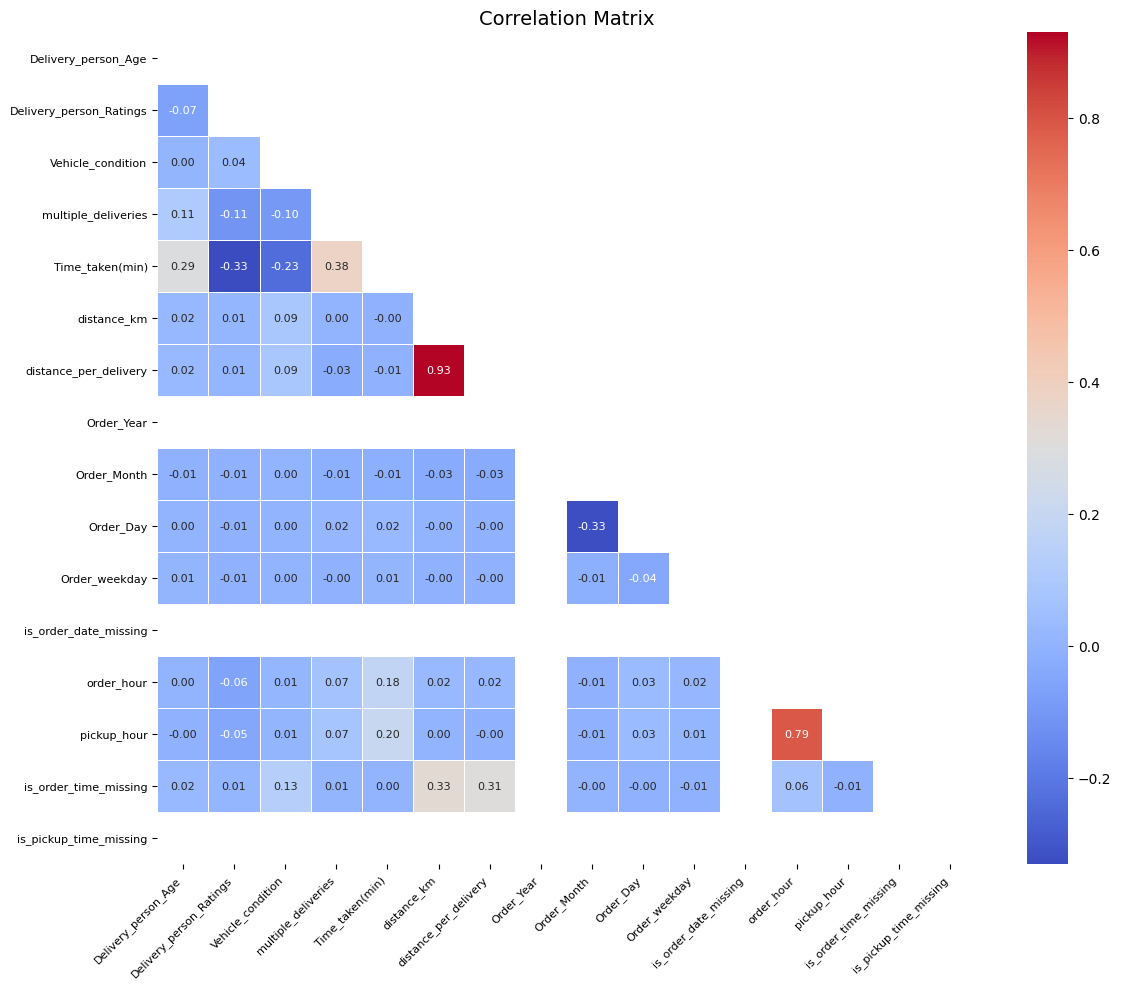

In [594]:
plot_correlation_matrix(
    df_train_processed,
    mask_upper=True
)

In [595]:
from sklearn.model_selection import train_test_split

X = df_train_processed.drop(columns=[target_col])
y = df_train_processed[target_col]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape, X_test.shape)

(36474, 23) (9119, 23)


In [596]:
num_cols = [
    "Delivery_person_Age",
    "Delivery_person_Ratings",
    "multiple_deliveries",
    "order_hour",
    "pickup_hour",
    "Order_Year",
    "Order_Month",
    "Order_Day",
    "distance_km",
    "distance_per_delivery"
]

cat_nominal_cols = [
    "City",
    "Festival",
    "Type_of_order",
    "Type_of_vehicle",
    "Weatherconditions",
    "Order_weekday"
]

cat_ordinal_cols = [
    "Road_traffic_density"
]

ordinal_categories = [
    ["Low", "Medium", "High", "Jam"]
]



In [597]:
def build_pipeline_regression(
    X_train, X_test, y_train, y_test,
    num_cols,
    cat_nominal_cols,
    cat_ordinal_cols,
    ordinal_categories,
    model_class,
    model_name="Model",
    model_params=None
):
    import time
    import numpy as np
    from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
    from sklearn.model_selection import cross_val_score
    from sklearn.pipeline import Pipeline
    from sklearn.compose import ColumnTransformer
    from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
    from sklearn.impute import SimpleImputer

    if model_params is None:
        model_params = {}

    # =========================
    # NUMERICAL PIPELINE
    # =========================
    num_pipe = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ])

    # =========================
    # NOMINAL PIPELINE
    # =========================
    cat_nominal_pipe = Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(handle_unknown="ignore"))
    ])

    # =========================
    # ORDINAL PIPELINE
    # =========================
    cat_ordinal_pipe = Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OrdinalEncoder(categories=ordinal_categories))
    ])

    # =========================
    # COLUMN TRANSFORMER
    # =========================
    transformers = []

    if num_cols:
        transformers.append(("num", num_pipe, num_cols))

    if cat_nominal_cols:
        transformers.append(("cat_nominal", cat_nominal_pipe, cat_nominal_cols))

    if cat_ordinal_cols:
        transformers.append(("cat_ordinal", cat_ordinal_pipe, cat_ordinal_cols))

    preprocessor = ColumnTransformer(transformers)

    model = Pipeline([
        ("prep", preprocessor),
        ("model", model_class(**model_params))
    ])

    # =========================
    # TRAIN
    # =========================
    start = time.time()
    model.fit(X_train, y_train)
    train_time = time.time() - start

    y_pred = model.predict(X_test)

    # =========================
    # METRICS
    # =========================
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)

    cv_rmse = np.sqrt(-cross_val_score(
        model,
        X_train,
        y_train,
        cv=5,
        scoring="neg_mean_squared_error"
    ).mean())

    print("\n" + "="*80)
    print(model_name)
    print("="*80)
    print("MAE :", round(mae, 2))
    print("RMSE :", round(rmse, 2))
    print("R2 :", round(r2, 4))
    print("CV RMSE :", round(cv_rmse, 2))

    return {
        "name": model_name,
        "model": model,
        "mae": mae,
        "rmse": rmse,
        "r2": r2,
        "cv_rmse": cv_rmse,
        "train_time": train_time
    }

In [598]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
results = []

results.append(build_pipeline_regression(
    X_train, X_test, y_train, y_test,
    num_cols,
    cat_nominal_cols,
    cat_ordinal_cols,
    ordinal_categories,
    LinearRegression,
    "Linear Regression"
))

results.append(build_pipeline_regression(
    X_train, X_test, y_train, y_test,
    num_cols,
    cat_nominal_cols,
    cat_ordinal_cols,
    ordinal_categories,
    RandomForestRegressor,
    "Random Forest",
    model_params={
        "n_estimators": 200,
        "max_depth": 10,
        "random_state": 42,
        "n_jobs": -1
    }
))


Linear Regression
MAE : 5.09
RMSE : 6.43
R2 : 0.5279
CV RMSE : 6.45

Random Forest
MAE : 4.14
RMSE : 5.31
R2 : 0.6781
CV RMSE : 5.32
